# Customer Churn Prediction

### 1. Introduction

* Customer churn occurs when a customer **stops using a company's services**.
* This project uses machine learning to **predict customer churn** in a telecommunications company.

### 2. Business Context & Problem Statement

* Customer churn can lead to **revenue loss and increased customer acquisition costs**.
* The company wants to identify customers who are **likely to leave** based on their customer, service, contract, and billing information.
* **Target:** `Churn` → `Yes` / `No`
* **ML Task:** Binary Classification

### 3. Business Objective

* Build a model to **predict customer churn**.
* Identify **high-risk customers** and the factors influencing their predictions.
* Provide insights that can support **customer retention strategies**.


### Import the Libraries

In [73]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,f1_score,classification_report,recall_score,precision_score,confusion_matrix,roc_curve,auc ,roc_auc_score
import sys
from pathlib import Path 
sys.path.insert(0, str(Path.cwd().parent))
from src.preprocessing import (
    clf_pipeline,
    rf_model,
    create_xgb_pipeline
)

In [74]:
df = pd.read_csv('../data/Telco_Customer_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [75]:
print(f'Your rows arem{df.shape[0]} and your columns are {df.shape[1]}.')

Your rows arem7043 and your columns are 21.


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [77]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
original_rows = len(df)
df = df.dropna(subset=['TotalCharges'])
print(f"Total dropped rows with NaN : {original_rows - len(df)}")

Total dropped rows with NaN : 11


In [78]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [79]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges','TotalCharges','tenure']
categorical_features = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines',
                        'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
                        'StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']

In [80]:
X = df[numeric_features + categorical_features]
y = df[target_feature]

In [81]:
from collections import Counter 
Counter(y)

## The dataset is imbalanced if the yes and No are not 50 , 50

Counter({'No': 5163, 'Yes': 1869})

In [82]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, stratify=y)

In [83]:
y_train = y_train.map({'Yes':1,'No':0})
y_test = y_test.map({'Yes':1,'No':0})
y = y.map({'Yes':1,'No':0})

In [84]:
print(f"Original data Churn Rate : {y.mean():.2f}")
print(f"Training data Churn Rate : {y_train.mean():.2f}")
print(f"Testing data Churn Rate : {y_test.mean():.2f}")


Original data Churn Rate : 0.27
Training data Churn Rate : 0.27
Testing data Churn Rate : 0.27


In [85]:
clf_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['MonthlyCharges','TotalCharges','tenure',...,'Contract', 'PaperlessBilling','PaymentMethod']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [86]:
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[0 0 0 ... 1 1 0]


In [87]:
y_proba = clf_pipeline.predict_proba(X_test)[:,1]
print(y_proba)

[0.44943096 0.46929593 0.06801953 ... 0.72747872 0.57500634 0.47143185]


In [88]:
print(recall_score(y_test,y_predict))

0.7932263814616756


In [89]:
print(confusion_matrix(y_test,y_predict))

[[1140  409]
 [ 116  445]]


In [90]:
print(precision_score(y_test,y_predict))

0.5210772833723654


In [91]:
print(accuracy_score(y_test,y_predict))

0.7511848341232228


In [92]:
print(f1_score(y_test,y_predict))


0.6289752650176679


In [93]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1549
           1       0.52      0.79      0.63       561

    accuracy                           0.75      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.75      0.76      2110



In [94]:
fpr, tpr, threshholds = roc_curve(y_test,y_proba)
roc_auc = auc(fpr,tpr)
print(roc_auc)

0.8539981518753401


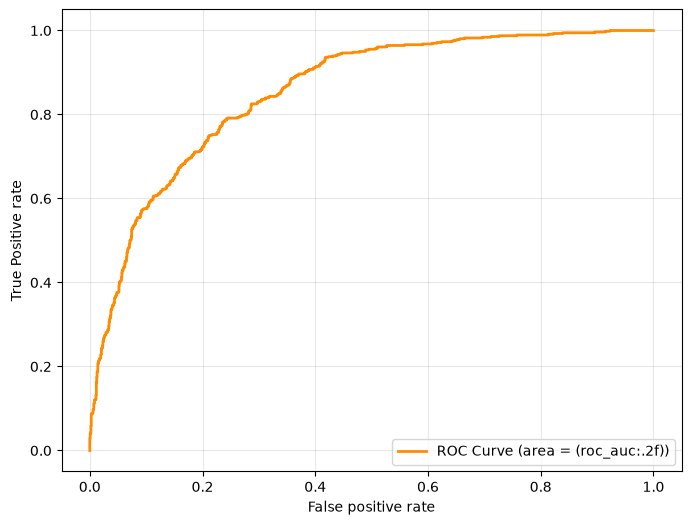

In [95]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr, color='darkorange', lw=2, label=(f'ROC Curve (area = (roc_auc:.2f))'))
plt.xlabel("False positive rate")
plt.ylabel("True Positive rate")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [96]:
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['MonthlyCharges','TotalCharges','tenure',...,'Contract', 'PaperlessBilling','PaymentMethod']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [97]:
y_predict_rf = rf_model.predict(X_test)
print(y_predict_rf)

[0 1 0 ... 1 0 0]


In [98]:
y_proba_rf = rf_model.predict_proba(X_test)[:,1]
print(y_proba_rf)

[0.35  0.675 0.045 ... 0.505 0.39  0.235]


In [99]:
print(confusion_matrix(y_test,y_predict_rf))

[[1286  263]
 [ 217  344]]


In [100]:
print(classification_report(y_test,y_predict_rf))

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      1549
           1       0.57      0.61      0.59       561

    accuracy                           0.77      2110
   macro avg       0.71      0.72      0.72      2110
weighted avg       0.78      0.77      0.78      2110



In [101]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test,y_proba_rf)
roc_auc_rf = auc(fpr_rf,tpr_rf)
print(roc_auc_rf)

0.8250840919735463


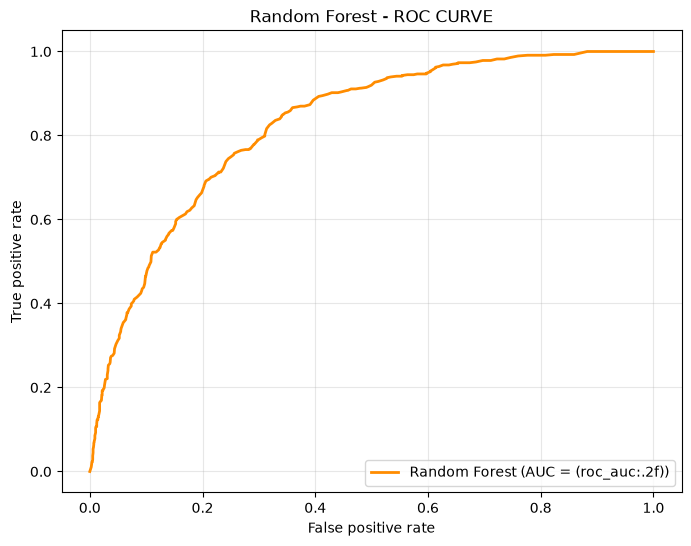

In [102]:
plt.figure(figsize=(8,6))
plt.plot(fpr_rf,tpr_rf, color='darkorange', lw=2, label=f'Random Forest (AUC = (roc_auc:.2f))')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Random Forest - ROC CURVE")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [103]:
from sklearn.model_selection import cross_val_score
cv_auc = cross_val_score(clf_pipeline,X_train,y_train,scoring='roc_auc', cv=5)

print("Logistic Regression CV AUC :", cv_auc.mean())

Logistic Regression CV AUC : 0.8391295776634807


In [104]:
cv_auc = cross_val_score(rf_model,X_train,y_train,scoring='roc_auc',cv=5)

print('Random Forest CV AUC:', cv_auc.mean())

Random Forest CV AUC: 0.8216511289272705


In [105]:
from sklearn.model_selection import GridSearchCV 

param_grid = {
    'model__n_estimators' : [200,400],
    'model__max_depth' : [None,10,20],
    'model__min_samples_split' : [2,10],
    'model__min_samples_leaf' : [1,5]
}

In [106]:
grid_rf = GridSearchCV(rf_model,param_grid, scoring='roc_auc',cv=3,n_jobs=-1,verbose=2)


In [107]:
grid_rf.fit(X_train,y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 5], 'model__min_samples_split': [2, 10], 'model__n_estimators': [200, 400]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See 

In [108]:
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)


Best RF Params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best RF CV AUC: 0.8421627003448898


In [109]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, thresholds_rf=roc_curve(y_test,y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf,tpr_rf)
print(roc_auc_rf)

print(accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

0.8562053144516213
0.7725118483412322
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1549
           1       0.55      0.79      0.65       561

    accuracy                           0.77      2110
   macro avg       0.73      0.78      0.74      2110
weighted avg       0.81      0.77      0.78      2110



In [110]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({
    'feature' : feature_names,
    'importance' : importances
}).sort_values(by='importance', ascending=False)


feat_imp.head(15)

,feature,importance
35,cat__Contract_Month-to-month,0.135945
2,num__tenure,0.124971
1,num__TotalCharges,0.097221
0,num__MonthlyCharges,0.071148
17,cat__OnlineSecurity_No,0.066873
37,cat__Contract_Two year,0.065090
26,cat__TechSupport_No,0.052273
15,cat__InternetService_Fiber optic,0.041255
42,cat__PaymentMethod_Electronic check,0.031880
36,cat__Contract_One year,0.021819


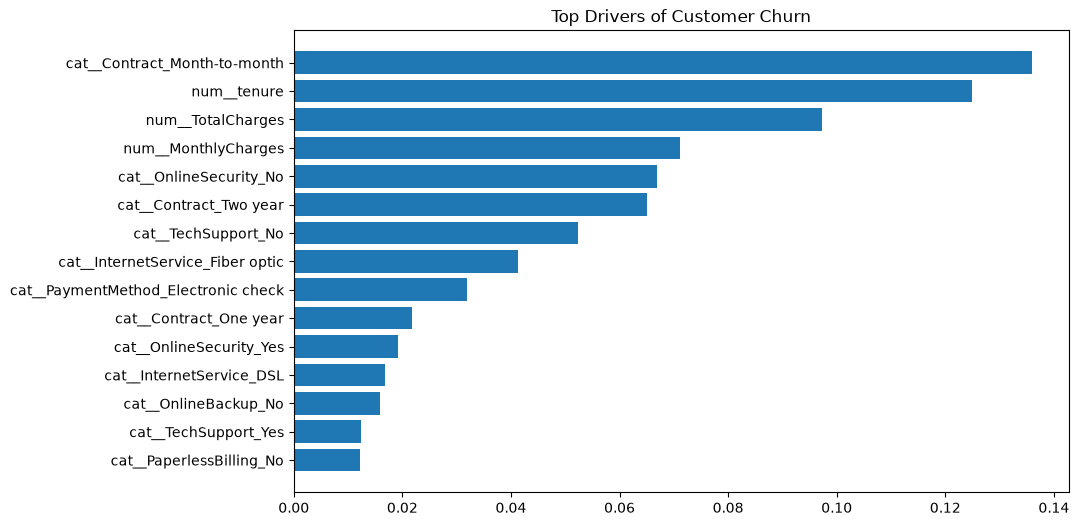

In [111]:
top_features = feat_imp.head(15)
plt.figure(figsize=(10,6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Customer Churn")
plt.show()

In [112]:
thresholds = np.arange(0.1,0.9,0.05)

results = []
for t in thresholds:
    y_pred_custom = (y_pred_proba_rf >=t).astype(int)

    precision = precision_score(y_test,y_pred_custom)
    recall = recall_score(y_test,y_pred_custom)
    f1  = f1_score(y_test,y_pred_custom)

    results.append((t,precision,recall,f1))

    results_df = pd.DataFrame(results, columns=['thresholds','precision','recall','f1'])
    results_df



In [113]:
results_df

,thresholds,precision,recall,f1
0,0.10,0.335358,0.983957,0.500227
1,0.15,0.358306,0.980392,0.524809
2,0.20,0.381254,0.964349,0.546465
3,0.25,0.409302,0.941176,0.570502
4,0.30,0.432523,0.919786,0.588369
5,0.35,0.466235,0.898396,0.613886
6,0.40,0.492000,0.877005,0.630365
7,0.45,0.519956,0.836007,0.641148
8,0.50,0.550436,0.787879,0.648094
9,0.55,0.581590,0.743316,0.652582


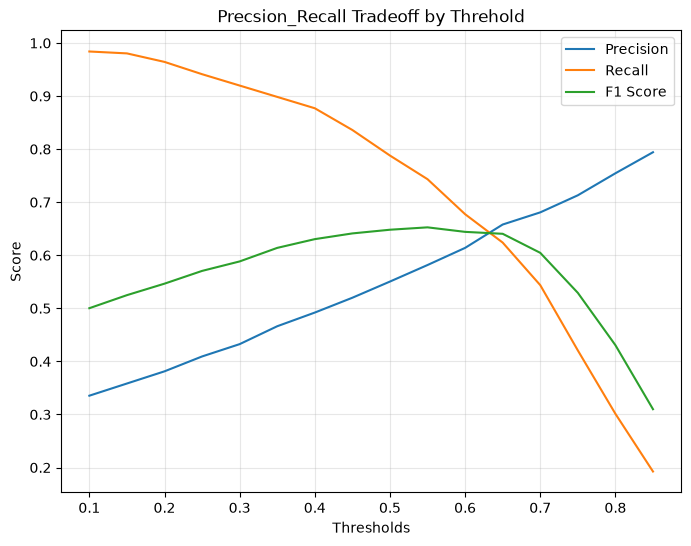

In [114]:
plt.figure(figsize=(8,6))
plt.plot(results_df['thresholds'], results_df['precision'], label='Precision')
plt.plot(results_df['thresholds'], results_df['recall'], label='Recall')
plt.plot(results_df['thresholds'], results_df['f1'], label='F1 Score')
plt.xlabel('Thresholds')
plt.ylabel('Score')
plt.legend()
plt.title('Precsion_Recall Tradeoff by Threhold')
plt.grid(alpha=0.3)
plt.show()

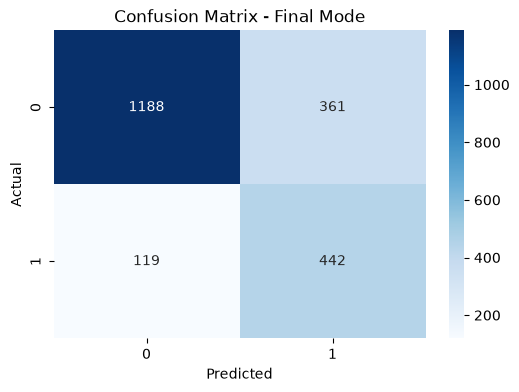

In [115]:
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test,y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Mode")
plt.show()

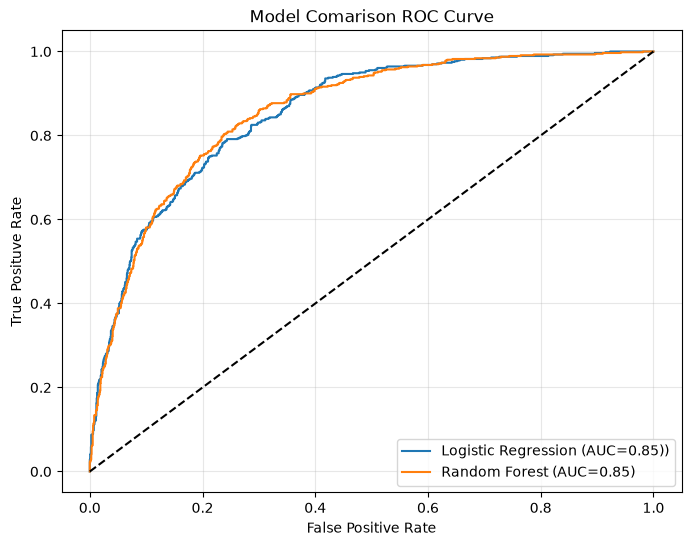

In [116]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr, label=f'Logistic Regression (AUC={roc_auc:.2f}))')
plt.plot(fpr_rf,tpr_rf,label=f'Random Forest (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Posituve Rate")
plt.title("Model Comarison ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [117]:
churn_proba = y_pred_proba_rf
risk_df = pd.DataFrame({
    'churn_probability' : churn_proba
})

risk_df['risk_level'] = pd.cut(
    risk_df['churn_probability'], 
    bins=[0,0.3,0.6,1],
    labels=['Low Risk','Medium Risk','High Risk']
)

risk_df['risk_level'].value_counts()

risk_level
Low Risk       917
High Risk      619
Medium Risk    574
Name: count, dtype: int64

In [118]:
import joblib
joblib.dump(clf_pipeline, "Logistic_model.pkl")
joblib.dump(best_rf, "rf_model.pkl")

['rf_model.pkl']

In [119]:
import sklearn 
print(sklearn.__version__)

1.9.0


In [120]:
%pip install shap


Note: you may need to restart the kernel to use updated packages.


In [121]:
import shap 
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)

In [122]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

In [123]:
rf_classifier = best_rf.named_steps['model']
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_train_transformed)

In [124]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed)

<class 'numpy.ndarray'>
4922
(44, 2)
[[ 0.83844845 -0.48592984 -0.74876085 ...  0.          1.
   0.        ]
 [-1.16804538 -0.81223639 -0.70798863 ...  0.          1.
   0.        ]
 [-1.51439452 -0.78316131 -0.25949422 ...  1.          0.
   0.        ]
 ...
 [ 0.70856752 -0.86961502 -1.15648305 ...  0.          1.
   0.        ]
 [-0.32548448 -0.98119806 -1.27879971 ...  1.          0.
   0.        ]
 [ 0.15241073 -0.92108606 -1.19725527 ...  0.          1.
   0.        ]]


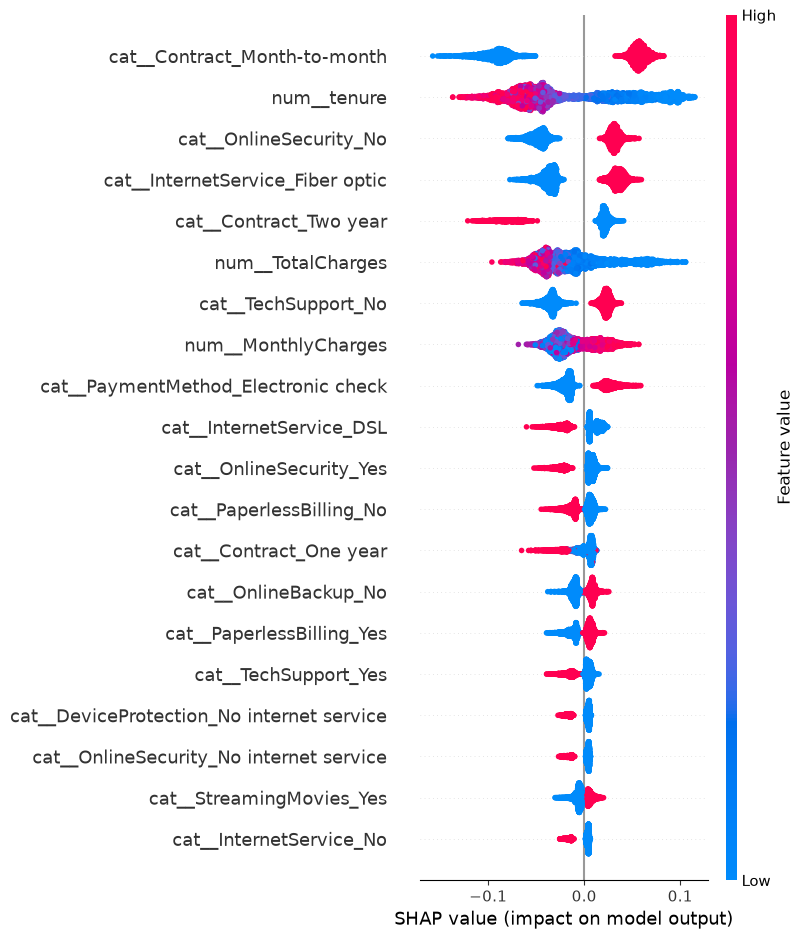

In [125]:
shap.summary_plot(
    shap_values[:,:,1],
    X_train_transformed,
    feature_names = feature_names
)

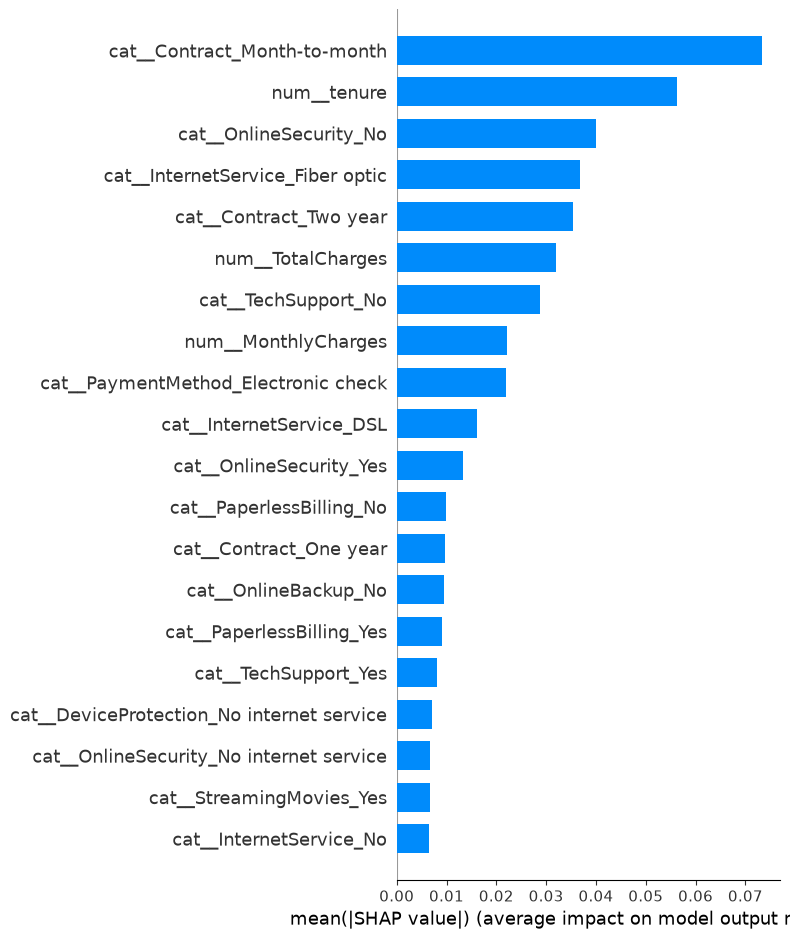

In [126]:
shap.summary_plot(
    shap_values[:,:,1],
    X_train_transformed,
    feature_names = feature_names,
    plot_type = 'bar'
)

In [127]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

In [128]:
xgb_model = create_xgb_pipeline(scale_pos_weight)

In [129]:
xgb_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['MonthlyCharges','TotalCharges','tenure',...,'Contract', 'PaperlessBilling','PaymentMethod']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [130]:
y_predict_xgb = xgb_model.predict(X_test)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_predict_xgb))

print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1549
           1       0.54      0.78      0.64       561

    accuracy                           0.77      2110
   macro avg       0.72      0.77      0.73      2110
weighted avg       0.81      0.77      0.78      2110

ROC AUC: 0.853120695428826


In [132]:
performance_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC AUC": [0.86, 0.85, round(roc_auc_score(y_test, y_proba_xgb), 2)],
    "F1 Score": [0.64, 0.65, round(f1_score(y_test, y_predict_xgb), 2)],
    "Precision": [0.52, 0.56, round(precision_score(y_test, y_predict_xgb), 2)],
    "Recall": [0.84, 0.78, round(recall_score(y_test, y_predict_xgb), 2)]
})

performance_df

,Model,ROC AUC,F1 Score,Precision,Recall
0,Logistic Regression,0.86,0.64,0.52,0.84
1,Random Forest,0.85,0.65,0.56,0.78
2,XGBoost,0.85,0.64,0.54,0.78


In [133]:
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']